# Notebook 2: Variable Construction
**Course:** Economic and Social Statistics (AST3336) — Year 3, Semester 2
**Institution:** University of Rwanda, College of Business and Economics
**Group:** Group 1 — AHS 2024: Poverty & Demographics

---

## Objective
Construct all analysis variables from the merged dataset.

| Variable | Type | Role |
|----------|------|------|
| `poor` | Binary (0/1) | Dependent variable — Logit/Probit |
| `extreme_poor` | Binary (0/1) | Robustness check |
| `welfare_quintile` | Ordinal (1–5) | Dependent variable — OLS |
| `head_sex` | Binary (1=Male, 0=Female) | Key regressor |
| `head_age` | Continuous | Key regressor |
| `head_age_sq` | Continuous | Non-linear age effect |
| `hh_size` | Continuous | Key regressor |
| `dep_ratio` | Continuous | Key regressor |
| `livelihood_ag` | Binary (1=Ag, 0=Non-ag) | Key regressor |
| `land_ha` | Continuous | Key regressor |
| `land_ha_log` | Continuous | Log-transformed land |
| `province_name` | String | Geographic control |
| Province dummies | Binary | For regression |

**Input:** `data/ahs2024_merged.csv`
**Output:** `data/ahs2024_analysis.csv`

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH   = r'..\data\ahs2024_merged.csv'
OUTPUT_PATH = r'..\data\ahs2024_analysis.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} households, {df.shape[1]} variables')
print(f'Columns: {df.columns.tolist()}')
print(f'\nProvince check:')
print(df['province_name'].value_counts())

Dataset loaded: 3724 households, 20 variables
Columns: ['hhid', 'clust', 'province_name', 'district_name', 's0q14', 's0q15', 's0q16', 'weight', 'hh_size', 'head_sex', 'head_age', 'n_children', 'n_elderly', 'n_working', 'dep_ratio', 'quintile', 'pov_jan', 'epov_jan', 'total_agr_land', 'n_plots']

Province check:
province_name
South     1066
East      1013
West       834
North      767
Kigali      44
Name: count, dtype: int64


## 2. Dependent Variables

In [2]:
# -------------------------------------------------------
# 2.1 Poverty status — binary (Logit/Probit DV)
# -------------------------------------------------------
df['poor'] = pd.to_numeric(df['pov_jan'], errors='coerce')
df['poor'] = df['poor'].apply(lambda x: 1 if x == 1 else (0 if x == 0 else np.nan))

print('Poverty status (1=Poor, 0=Not Poor):')
print(df['poor'].value_counts(dropna=False))
print(f'Poverty rate: {df["poor"].mean()*100:.2f}%')

Poverty status (1=Poor, 0=Not Poor):
poor
0    2835
1     889
Name: count, dtype: int64
Poverty rate: 23.87%


In [3]:
# -------------------------------------------------------
# 2.2 Extreme poverty — binary (robustness check)
# -------------------------------------------------------
df['extreme_poor'] = pd.to_numeric(df['epov_jan'], errors='coerce')
df['extreme_poor'] = df['extreme_poor'].apply(lambda x: 1 if x == 1 else (0 if x == 0 else np.nan))

print('Extreme poverty (1=Extremely Poor, 0=Not):')
print(df['extreme_poor'].value_counts(dropna=False))
print(f'Extreme poverty rate: {df["extreme_poor"].mean()*100:.2f}%')

Extreme poverty (1=Extremely Poor, 0=Not):
extreme_poor
0    3592
1     132
Name: count, dtype: int64
Extreme poverty rate: 3.54%


In [4]:
# -------------------------------------------------------
# 2.3 Welfare quintile — ordinal 1-5 (OLS DV)
# -------------------------------------------------------
df['welfare_quintile'] = pd.to_numeric(df['quintile'], errors='coerce')

print('Welfare quintile (1=Poorest, 5=Richest):')
print(df['welfare_quintile'].value_counts(dropna=False).sort_index())
print(f'\nMean quintile: {df["welfare_quintile"].mean():.3f}')
print(f'Missing: {df["welfare_quintile"].isna().sum()}')

Welfare quintile (1=Poorest, 5=Richest):
welfare_quintile
1.0000    597
2.0000    836
3.0000    889
4.0000    923
5.0000    479
Name: count, dtype: int64

Mean quintile: 2.960
Missing: 0


## 3. Household Head Characteristics

In [5]:
# -------------------------------------------------------
# 3.1 Sex of household head (already binary from Notebook 1)
# 1 = Male-headed, 0 = Female-headed
# -------------------------------------------------------
df['head_sex'] = pd.to_numeric(df['head_sex'], errors='coerce')
df['head_sex_label'] = df['head_sex'].map({1: 'Male', 0: 'Female'})

n_male   = (df['head_sex'] == 1).sum()
n_female = (df['head_sex'] == 0).sum()
total    = n_male + n_female

print('Sex of household head:')
print(f'Male-headed:   {n_male} ({n_male/total*100:.1f}%)')
print(f'Female-headed: {n_female} ({n_female/total*100:.1f}%)')
print(f'Missing: {df["head_sex"].isna().sum()}')

Sex of household head:
Male-headed:   2734 (73.4%)
Female-headed: 990 (26.6%)
Missing: 0


In [6]:
# -------------------------------------------------------
# 3.2 Age of household head
# -------------------------------------------------------
df['head_age'] = pd.to_numeric(df['head_age'], errors='coerce')

# Clean implausible values
df.loc[df['head_age'] < 15,  'head_age'] = np.nan
df.loc[df['head_age'] > 100, 'head_age'] = np.nan

# Age squared for non-linear effect
df['head_age_sq'] = df['head_age'] ** 2

# Age group categories
df['head_age_group'] = pd.cut(
    df['head_age'],
    bins=[0, 30, 45, 60, 120],
    labels=['15-30', '31-45', '46-60', '61+']
)

print('Age of household head summary:')
print(df['head_age'].describe())
print('\nAge group distribution:')
print(df['head_age_group'].value_counts().sort_index())

Age of household head summary:
count   3721.0000
mean      49.5493
std       15.6115
min       19.0000
25%       37.0000
50%       47.0000
75%       62.0000
max       97.0000
Name: head_age, dtype: float64

Age group distribution:
head_age_group
15-30     384
31-45    1354
46-60     973
61+      1010
Name: count, dtype: int64


## 4. Household Structure

In [7]:
# -------------------------------------------------------
# 4.1 Household size
# -------------------------------------------------------
df['hh_size'] = pd.to_numeric(df['hh_size'], errors='coerce')
df.loc[df['hh_size'] > 20, 'hh_size'] = np.nan

df['hh_size_cat'] = pd.cut(
    df['hh_size'],
    bins=[0, 2, 4, 6, 100],
    labels=['1-2', '3-4', '5-6', '7+']
)

print('Household size summary:')
print(df['hh_size'].describe())
print('\nHH size categories:')
print(df['hh_size_cat'].value_counts().sort_index())

Household size summary:
count   3724.0000
mean       4.3749
std        1.9522
min        1.0000
25%        3.0000
50%        4.0000
75%        6.0000
max       14.0000
Name: hh_size, dtype: float64

HH size categories:
hh_size_cat
1-2     637
3-4    1403
5-6    1159
7+      525
Name: count, dtype: int64


In [8]:
# -------------------------------------------------------
# 4.2 Dependency ratio
# -------------------------------------------------------
df['dep_ratio'] = pd.to_numeric(df['dep_ratio'], errors='coerce')
df.loc[df['dep_ratio'] > 10, 'dep_ratio'] = np.nan

df['dep_ratio_cat'] = pd.cut(
    df['dep_ratio'],
    bins=[-0.01, 0, 1, 2, 100],
    labels=['No dependents', 'Low (0-1)', 'Medium (1-2)', 'High (2+)']
)

print('Dependency ratio summary:')
print(df['dep_ratio'].describe())
print('\nDependency ratio categories:')
print(df['dep_ratio_cat'].value_counts().sort_index())

Dependency ratio summary:
count   3467.0000
mean       0.8884
std        0.7616
min        0.0000
25%        0.4000
50%        0.7500
75%        1.0000
max        6.0000
Name: dep_ratio, dtype: float64

Dependency ratio categories:
dep_ratio_cat
No dependents     488
Low (0-1)        2149
Medium (1-2)      676
High (2+)         154
Name: count, dtype: int64


## 5. Livelihood Activity

In [9]:
# -------------------------------------------------------
# 5.1 Main livelihood — binary
# s0q14: 'Agriculture' or 'No agricultural activities'
# -------------------------------------------------------
print('Raw s0q14 values:')
print(df['s0q14'].value_counts(dropna=False))

df['livelihood_ag'] = df['s0q14'].astype(str).str.lower().apply(
    lambda x: 1 if 'agri' in x else (0 if 'no' in x or 'non' in x else np.nan)
)
df['livelihood_label'] = df['livelihood_ag'].map({1: 'Agriculture', 0: 'Non-Agriculture'})

print('\nLivelihood (1=Agriculture, 0=Non-ag):')
print(df['livelihood_ag'].value_counts(dropna=False))

Raw s0q14 values:
s0q14
Agriculture                   3304
No agricultural activities     420
Name: count, dtype: int64

Livelihood (1=Agriculture, 0=Non-ag):
livelihood_ag
1    3724
Name: count, dtype: int64


In [10]:
# -------------------------------------------------------
# 5.2 Agricultural activity type
# s0q15: Cropping, Livestock, Aquaculture, Forestry, Apiculture, Other
# -------------------------------------------------------
print('Raw s0q15 values:')
print(df['s0q15'].value_counts(dropna=False))

df['ag_activity'] = df['s0q15'].astype(str)
df['ag_activity'] = df['ag_activity'].replace('nan', 'Non-Agricultural')

Raw s0q15 values:
s0q15
Cropping     3296
NaN           420
Livestock       8
Name: count, dtype: int64


## 6. Land Variables

In [11]:
# -------------------------------------------------------
# Land area in hectares
# -------------------------------------------------------
df['land_ha'] = pd.to_numeric(df['total_agr_land'], errors='coerce')
df.loc[df['land_ha'] > 50, 'land_ha'] = np.nan

# Log transformation (add small constant for zeros)
df['land_ha_log'] = np.log(df['land_ha'] + 0.01)

# Land categories
df['land_cat'] = pd.cut(
    df['land_ha'],
    bins=[-0.01, 0.1, 0.5, 1.0, 100],
    labels=['< 0.1 ha', '0.1-0.5 ha', '0.5-1.0 ha', '> 1.0 ha']
)

print('Land area (ha) summary:')
print(df['land_ha'].describe())
print('\nLand categories:')
print(df['land_cat'].value_counts().sort_index())

Land area (ha) summary:
count   3717.0000
mean       0.4158
std        0.5180
min        0.0000
25%        0.1435
50%        0.2784
75%        0.5132
max       12.4876
Name: land_ha, dtype: float64

Land categories:
land_cat
< 0.1 ha       614
0.1-0.5 ha    2130
0.5-1.0 ha     692
> 1.0 ha       281
Name: count, dtype: int64


## 7. Geographic Variables

In [12]:
# -------------------------------------------------------
# Province — already string from Notebook 1
# Create dummy variables (Kigali = reference category)
# -------------------------------------------------------
print('Province distribution:')
print(df['province_name'].value_counts())

# Province dummies
for prov in ['South', 'West', 'North', 'East']:
    df[f'd_{prov.lower()}'] = (df['province_name'] == prov).astype(int)

print('\nProvince dummies created (reference = Kigali):')
for prov in ['South', 'West', 'North', 'East']:
    print(f'  d_{prov.lower()}: {df[f"d_{prov.lower()}"].sum()} households')

Province distribution:
province_name
South     1066
East      1013
West       834
North      767
Kigali      44
Name: count, dtype: int64

Province dummies created (reference = Kigali):
  d_south: 1066 households
  d_west: 834 households
  d_north: 767 households
  d_east: 1013 households


## 8. Final Analysis Dataset

In [13]:
# Select final analysis variables
analysis_vars = [
    # Identifiers & design
    'hhid', 'clust', 'weight',
    # Geographic
    'province_name', 'district_name',
    'd_south', 'd_west', 'd_north', 'd_east',
    # Dependent variables
    'poor', 'extreme_poor', 'welfare_quintile',
    # Household head
    'head_sex', 'head_sex_label', 'head_age', 'head_age_sq', 'head_age_group',
    # Household structure
    'hh_size', 'hh_size_cat', 'dep_ratio', 'dep_ratio_cat',
    'n_children', 'n_elderly', 'n_working',
    # Livelihood
    'livelihood_ag', 'livelihood_label', 'ag_activity',
    # Land
    'land_ha', 'land_ha_log', 'land_cat', 'n_plots'
]

# Keep only available columns
analysis_vars = [v for v in analysis_vars if v in df.columns]
df_analysis = df[analysis_vars].copy()

print(f'Final analysis dataset: {df_analysis.shape}')
print(f'\nVariables:')
for v in df_analysis.columns:
    print(f'  {v}')

Final analysis dataset: (3724, 31)

Variables:
  hhid
  clust
  weight
  province_name
  district_name
  d_south
  d_west
  d_north
  d_east
  poor
  extreme_poor
  welfare_quintile
  head_sex
  head_sex_label
  head_age
  head_age_sq
  head_age_group
  hh_size
  hh_size_cat
  dep_ratio
  dep_ratio_cat
  n_children
  n_elderly
  n_working
  livelihood_ag
  livelihood_label
  ag_activity
  land_ha
  land_ha_log
  land_cat
  n_plots


In [14]:
# Missing values summary
print('=== MISSING VALUES ===')
missing = df_analysis.isnull().sum()
missing_pct = (missing / len(df_analysis) * 100).round(2)
missing_df = pd.DataFrame({'N missing': missing, '% missing': missing_pct})
print(missing_df[missing_df['N missing'] > 0])

=== MISSING VALUES ===
                N missing  % missing
head_age                3     0.0800
head_age_sq             3     0.0800
head_age_group          3     0.0800
dep_ratio             257     6.9000
dep_ratio_cat         257     6.9000
land_ha                 7     0.1900
land_ha_log             7     0.1900
land_cat                7     0.1900


In [15]:
# Summary statistics
print('=== SUMMARY STATISTICS ===')
cont_vars = ['head_age', 'hh_size', 'dep_ratio', 'land_ha', 'welfare_quintile']
print(df_analysis[cont_vars].describe().round(3))

print('\n=== KEY RATES ===')
print(f'Poverty rate:        {df_analysis["poor"].mean()*100:.2f}%')
print(f'Extreme poverty:     {df_analysis["extreme_poor"].mean()*100:.2f}%')
print(f'Male-headed HHs:     {df_analysis["head_sex"].mean()*100:.2f}%')
print(f'Ag livelihood:       {df_analysis["livelihood_ag"].mean()*100:.2f}%')
print(f'Mean HH size:        {df_analysis["hh_size"].mean():.2f}')
print(f'Mean dep ratio:      {df_analysis["dep_ratio"].mean():.3f}')
print(f'Mean land (ha):      {df_analysis["land_ha"].mean():.4f}')

=== SUMMARY STATISTICS ===
       head_age   hh_size  dep_ratio   land_ha  welfare_quintile
count 3721.0000 3724.0000  3467.0000 3717.0000         3724.0000
mean    49.5490    4.3750     0.8880    0.4160            2.9600
std     15.6110    1.9520     0.7620    0.5180            1.2760
min     19.0000    1.0000     0.0000    0.0000            1.0000
25%     37.0000    3.0000     0.4000    0.1430            2.0000
50%     47.0000    4.0000     0.7500    0.2780            3.0000
75%     62.0000    6.0000     1.0000    0.5130            4.0000
max     97.0000   14.0000     6.0000   12.4880            5.0000

=== KEY RATES ===
Poverty rate:        23.87%
Extreme poverty:     3.54%
Male-headed HHs:     73.42%
Ag livelihood:       100.00%
Mean HH size:        4.37
Mean dep ratio:      0.888
Mean land (ha):      0.4158


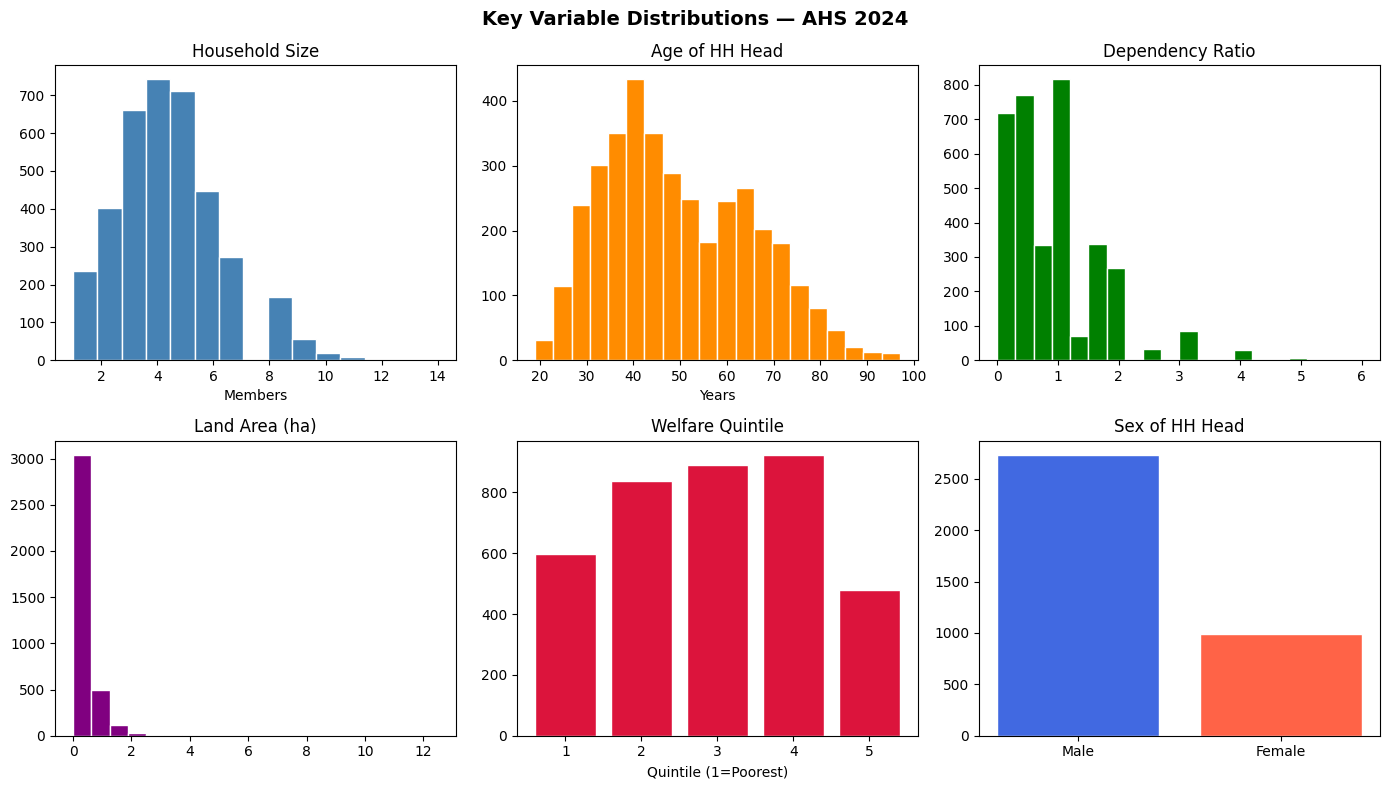

Figure saved ✓


In [16]:
# Quick distributions plot
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Key Variable Distributions — AHS 2024', fontsize=14, fontweight='bold')

axes[0,0].hist(df_analysis['hh_size'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0,0].set_title('Household Size')
axes[0,0].set_xlabel('Members')

axes[0,1].hist(df_analysis['head_age'].dropna(), bins=20, color='darkorange', edgecolor='white')
axes[0,1].set_title('Age of HH Head')
axes[0,1].set_xlabel('Years')

axes[0,2].hist(df_analysis['dep_ratio'].dropna(), bins=20, color='green', edgecolor='white')
axes[0,2].set_title('Dependency Ratio')

axes[1,0].hist(df_analysis['land_ha'].dropna(), bins=20, color='purple', edgecolor='white')
axes[1,0].set_title('Land Area (ha)')

q_counts = df_analysis['welfare_quintile'].value_counts().sort_index()
axes[1,1].bar(q_counts.index, q_counts.values, color='crimson', edgecolor='white')
axes[1,1].set_title('Welfare Quintile')
axes[1,1].set_xlabel('Quintile (1=Poorest)')

sex_counts = df_analysis['head_sex_label'].value_counts()
axes[1,2].bar(sex_counts.index, sex_counts.values,
              color=['royalblue','tomato'], edgecolor='white')
axes[1,2].set_title('Sex of HH Head')

plt.tight_layout()
plt.savefig(r'..\output\figures\variable_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

## 9. Save Analysis Dataset

In [17]:
df_analysis.to_csv(OUTPUT_PATH, index=False)

print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df_analysis.shape}')
print('\nReady for Notebook 3: Descriptive Analysis ✓')

Saved: ..\data\ahs2024_analysis.csv
Shape: (3724, 31)

Ready for Notebook 3: Descriptive Analysis ✓


## Variable Summary

| Variable | Construction | Values |
|----------|-------------|--------|
| `poor` | From `pov_jan` | 1=Poor, 0=Not Poor |
| `extreme_poor` | From `epov_jan` | 1=Extremely Poor, 0=Not |
| `welfare_quintile` | From `quintile` | 1 (poorest) to 5 (richest) |
| `head_sex` | From Notebook 1 | 1=Male, 0=Female |
| `head_age` | From Notebook 1 | Years (15–100) |
| `head_age_sq` | `head_age²` | Non-linear effect |
| `hh_size` | Count of members | Integer |
| `dep_ratio` | (children+elderly)/working | Continuous |
| `livelihood_ag` | From `s0q14` | 1=Agriculture, 0=Non-ag |
| `land_ha` | From `total_agr_land` | Hectares |
| `land_ha_log` | log(land_ha + 0.01) | Log scale |
| `d_south/west/north/east` | Province dummies | 0/1 (Kigali=ref) |

**Next:** `03_descriptive_analysis.ipynb`